In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
#Создание примера DataFrame
np.random.seed(42)  # для воспроизводимости
n_samples = 200
dohod = np.random.randint(30000, 100000, n_samples)  # Годовой доход (в долларах)
credit_his =  np.random.rand(n_samples)

# Преобразуем целевую переменную в бинарную (выдавать кредит или нет)
veroyatno_vydacha_credita  = 0.5 * dohod + 10000 * credit_his + np.random.normal(0, 5000, n_samples)
vydacha_credita  = (veroyatno_vydacha_credita > np.mean(veroyatno_vydacha_credita)).astype(int)  # 1 - выдавать, 0 - не выдавать
data = pd.DataFrame({'доход': dohod, 'кредитная_история': credit_his, 'выдача_кредита': vydacha_credita})

In [3]:
data

,доход,кредитная_история,выдача_кредита
0,45795,0.846661,0
1,30860,0.856324,0
2,84886,0.404508,1
3,36265,0.887770,0
4,67194,0.850928,1
...,...,...,...
195,91434,0.127690,1
196,73016,0.250016,1
197,37400,0.580544,0
198,72642,0.867117,1


In [15]:
#  Подготовка данных
X = data[['доход', 'кредитная_история']]
y = data['выдача_кредита']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Масштабирование признаков (для случайного леса не обязательно, но для примера оставим)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Случайный лес

In [17]:
# Случайный лес для классификации (без GridSearchCV, с заданными параметрами)
rf = RandomForestClassifier(n_estimators=150,  # Задаем количество деревьев
                            max_depth=6,       # Задаем максимальную глубину
                            min_samples_split=5, # Задаем минимальное количество образцов для разделения
                            min_samples_leaf=3,  # Задаем минимальное количество образцов в листе
                            random_state=42)    # Задаем зерно для воспроизводимости

rf.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=6, min_samples_leaf=3, min_samples_split=5,
                       n_estimators=150, random_state=42)

In [18]:
#  Оценка модели
y_pred_rf_t = rf.predict(X_train_scaled)
y_pred_rf = rf.predict(X_test_scaled)

accuracy_rf_t = accuracy_score(y_train, y_pred_rf_t)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Случайный лес: Accuracy train= {accuracy_rf_t:.2f}")
print(f"Случайный лес: Accuracy test = {accuracy_rf:.2f}")
print("\nClassification Report (Случайный лес):\n", classification_report(y_test, y_pred_rf))

Случайный лес: Accuracy train= 0.94
Случайный лес: Accuracy test = 0.85

Classification Report (Случайный лес):
               precision    recall  f1-score   support

           0       0.90      0.82      0.86        22
           1       0.80      0.89      0.84        18

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.86      0.85      0.85        40



In [14]:
# Предсказание для нового клиента
new_income = 60000
new_credit_history = 0.7

new_client = pd.DataFrame({'доход': [new_income], 'кредитная_история': [new_credit_history]})
new_client_scaled = scaler.transform(new_client)

vydacha = rf.predict(new_client_scaled)[0]
veroyatno  = rf.predict_proba(new_client_scaled)[0, 1]

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_income}, Кредитная история: {new_credit_history}")
print(f"Вероятность выдачи кредита: {veroyatno :.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - не выдать): {vydacha}")


Предсказание для нового клиента:
Доход: 60000, Кредитная история: 0.7
Вероятность выдачи кредита: 0.51
Решение о выдаче кредита (1 - выдать, 0 - не выдать): 1


# Случайный лес с GridSearchCV

In [6]:
# Случайный лес для классификации
param_grid = {'n_estimators': [50, 100, 200],  # Количество деревьев
              'max_depth': [4, 6, 8],       # Максимальная глубина дерева
              'min_samples_split': [2, 5, 10], # Минимальное количество образцов для разделения
              'min_samples_leaf': [1, 3, 5]}   # Минимальное количество образцов в листе

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train) # Обучаем на масштабированных данных (хотя это и не обязательно)

# Лучшая модель
best_rf = grid_search.best_estimator_
print("Лучшие параметры для случайного леса:", grid_search.best_params_)



Лучшие параметры для случайного леса: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [7]:
#  Оценка модели
y_pred_rf_t = best_rf.predict(X_train_scaled)
y_pred_rf = best_rf.predict(X_test_scaled)

accuracy_rf_t = accuracy_score(y_train, y_pred_rf_t)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Случайный лес: Accuracy train= {accuracy_rf_t:.2f}")
print(f"Случайный лес: Accuracy test = {accuracy_rf:.2f}")
print("\nClassification Report (Случайный лес):\n", classification_report(y_test, y_pred_rf))

Случайный лес: Accuracy train= 0.94
Случайный лес: Accuracy test = 0.88

Classification Report (Случайный лес):
               precision    recall  f1-score   support

           0       0.90      0.86      0.88        22
           1       0.84      0.89      0.86        18

    accuracy                           0.88        40
   macro avg       0.87      0.88      0.87        40
weighted avg       0.88      0.88      0.88        40



In [8]:
# Предсказание для нового клиента
new_income = 60000
new_credit_history = 0.7

new_client = pd.DataFrame({'доход': [new_income], 'кредитная_история': [new_credit_history]})
new_client_scaled = scaler.transform(new_client)

vydacha = best_rf.predict(new_client_scaled)[0]
veroyatno  = best_rf.predict_proba(new_client_scaled)[0, 1]

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_income}, Кредитная история: {new_credit_history}")
print(f"Вероятность выдачи кредита: {veroyatno :.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - не выдать): {vydacha}")


Предсказание для нового клиента:
Доход: 60000, Кредитная история: 0.7
Вероятность выдачи кредита: 0.60
Решение о выдаче кредита (1 - выдать, 0 - не выдать): 1


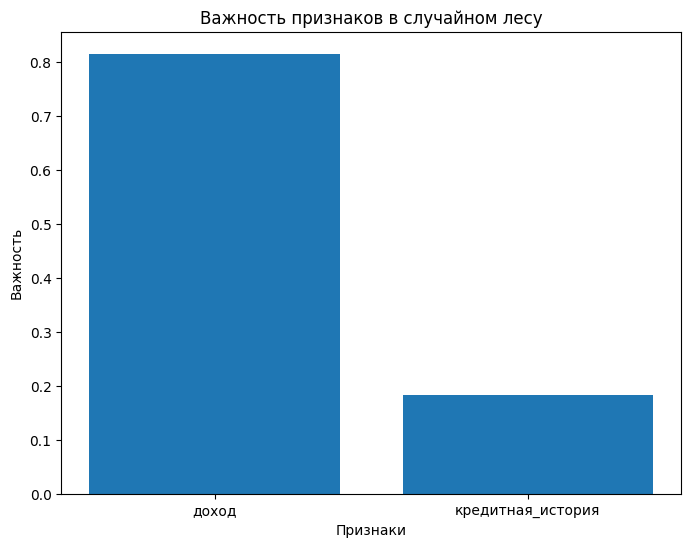

In [9]:
feature_importances = best_rf.feature_importances_
feature_names = X.columns
plt.figure(figsize=(8, 6))
plt.bar(feature_names, feature_importances)
plt.xlabel("Признаки")
plt.ylabel("Важность")
plt.title("Важность признаков в случайном лесу")
plt.show()